In [2]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('../data/noaa_cdc_uscensus.csv')

# Display the first few rows to verify
print(df.shape)
df.head()

(14544, 54)


,year,stateabbr_c,statedesc_c,locationname_c,category_c,locationid_c,measure_c,data_value_c,low_confidence_limit_c,high_confidence_limit_c,...,pct_female_u,cbsa_code_u,median_household_income_u,pct_bachelors_plus_u,pct_graduate_degree_u,pct_less_than_hs_u,pct_white_u,pct_black_u,pct_hispanic_u,pct_asian_u
0,2014,AL,Alabama,Mobile,Health Outcomes,150000,Chronic obstructive pulmonary disease among ad...,8.7,8.5,8.8,...,52.1,33660.0,43844.0,6.7,13.2,4.5,58.4,34.9,2.6,1.9
1,2014,AL,Alabama,Tuscaloosa,Health Outcomes,177256,Chronic obstructive pulmonary disease among ad...,9.1,8.9,9.4,...,51.8,46220.0,43567.0,5.6,14.1,4.5,61.6,33.2,2.8,1.2
2,2014,AL,Alabama,Birmingham,Health Outcomes,107000,Chronic obstructive pulmonary disease among ad...,9.4,9.3,9.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014,AL,Alabama,Montgomery,Health Outcomes,151000,Chronic obstructive pulmonary disease among ad...,8.6,8.5,8.8,...,52.0,33860.0,46977.0,6.2,16.0,5.2,50.5,43.0,3.1,1.7
4,2014,AL,Alabama,Huntsville,Health Outcomes,137000,Chronic obstructive pulmonary disease among ad...,7.5,7.4,7.7,...,50.7,26620.0,55881.0,6.9,22.7,3.8,68.2,21.5,4.9,2.2


# Pivoting the data

In [25]:
measure_specific = ['measureid_c', 'measure_c', 'data_value_c', 'low_confidence_limit_c',
                    'high_confidence_limit_c', 'category_c', 'categoryid_c', 'short_question_text_c']
index_cols = [c for c in df.columns if c not in measure_specific]

df_pivot = df.pivot(
    index=index_cols,
    columns='measureid_c',
    values='data_value_c'
).reset_index()

df_pivot.columns.name = None

print(df_pivot.shape)
df_pivot.head()

df_pivot.to_csv('../data/df_pivot.csv', index=False)


(1818, 54)


# Exploratory Analysis

In [4]:
#Year-wise country-wise data

df.groupby(['year', 'statedesc_c']).size().unstack(fill_value=0)

statedesc_c,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Florida,Georgia,Hawaii,...,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,West Virginia,Wisconsin,Wyoming
year,,,,,,,,,,,,,,,,,,,,,
2014,40,8,24,24,160,48,32,88,48,8,...,8,16,176,32,8,24,32,8,48,8
2015,40,8,24,24,160,48,32,88,48,8,...,8,16,176,32,8,24,32,8,48,8
2016,40,8,24,24,160,48,32,88,48,8,...,8,16,176,32,8,24,32,8,48,8
2017,40,8,24,24,160,48,32,88,48,8,...,8,16,176,32,8,24,32,8,48,8
2018,40,8,24,24,160,48,32,88,32,0,...,8,8,176,32,8,24,32,8,48,8
2019,40,8,24,24,160,48,32,88,32,0,...,8,8,176,32,8,24,32,8,48,8
2020,40,8,24,24,160,48,32,88,32,0,...,8,8,176,32,8,24,32,8,48,8
2021,40,8,24,24,160,48,32,0,32,0,...,8,8,176,32,8,24,32,8,48,8
2022,40,8,24,24,160,48,32,88,32,0,...,8,8,176,32,8,24,32,8,48,8


In [5]:
#Missing Values
missing = df.isnull().mean().mul(100).round(2).sort_values(ascending=False)
print(missing[missing > 0])  # only show columns that actually have missing values


tsun_n                       99.83
pct_asian_u                  16.17
median_household_income_u    16.17
msa_u                        16.17
total_population_u           16.17
median_age_u                 16.17
pct_male_u                   16.17
cbsa_code_u                  16.17
pct_female_u                 16.17
pct_bachelors_plus_u         16.17
pct_graduate_degree_u        16.17
pct_less_than_hs_u           16.17
pct_white_u                  16.17
pct_black_u                  16.17
pct_hispanic_u               16.17
cldd_n                        7.54
tavg_n                        7.43
htdd_n                        7.43
tmin_n                        6.99
emnt_n                        6.99
dt00_n                        6.99
dt32_n                        6.99
emxt_n                        6.93
dx90_n                        6.93
tmax_n                        6.93
dx32_n                        6.93
dx70_n                        6.93
prcp_n                        4.24
msa_n               

In [6]:
missing = pd.DataFrame({
    'total': df_pivot.shape[0],
    'missing': df_pivot.isnull().sum(),
    'pct_missing': df_pivot.isnull().mean().mul(100).round(2)
})
missing[missing['missing'] > 0].sort_values('pct_missing', ascending=False)


,total,missing,pct_missing
tsun_n,1818,1815,99.83
msa_u,1818,294,16.17
pct_hispanic_u,1818,294,16.17
pct_black_u,1818,294,16.17
pct_white_u,1818,294,16.17
pct_less_than_hs_u,1818,294,16.17
pct_graduate_degree_u,1818,294,16.17
pct_bachelors_plus_u,1818,294,16.17
median_household_income_u,1818,294,16.17
cbsa_code_u,1818,294,16.17


## State-wise split (2014)

statedesc_c
California       20.81
Texas            17.43
Florida           5.55
Arizona           4.22
Ohio              4.00
North Carolin     3.44
Colorado          2.99
Indiana           2.89
Michigan          2.68
Wisconsin         2.43
Oklahoma          2.19
Washington        2.02
Louisiana         1.98
Hawaii            1.96
Georgia           1.86
Alabama           1.81
Nevada            1.66
Tennessee         1.60
New York          1.47
New Mexico        1.46
Maryland          1.27
Illinois          1.27
Kansas            1.23
Pennsylvania      1.17
Connecticut       1.04
Oregon            0.95
Utah              0.93
Virginia          0.77
Iowa              0.70
Arkansas          0.69
Massachusetts     0.69
Kentucky          0.61
Alaska            0.60
Missouri          0.55
Nebraska          0.53
South Carolin     0.51
Mississippi       0.49
Montana           0.35
New Hampshire     0.22
Minnesota         0.22
New Jersey        0.17
South Dakota      0.14
Maine             0.14

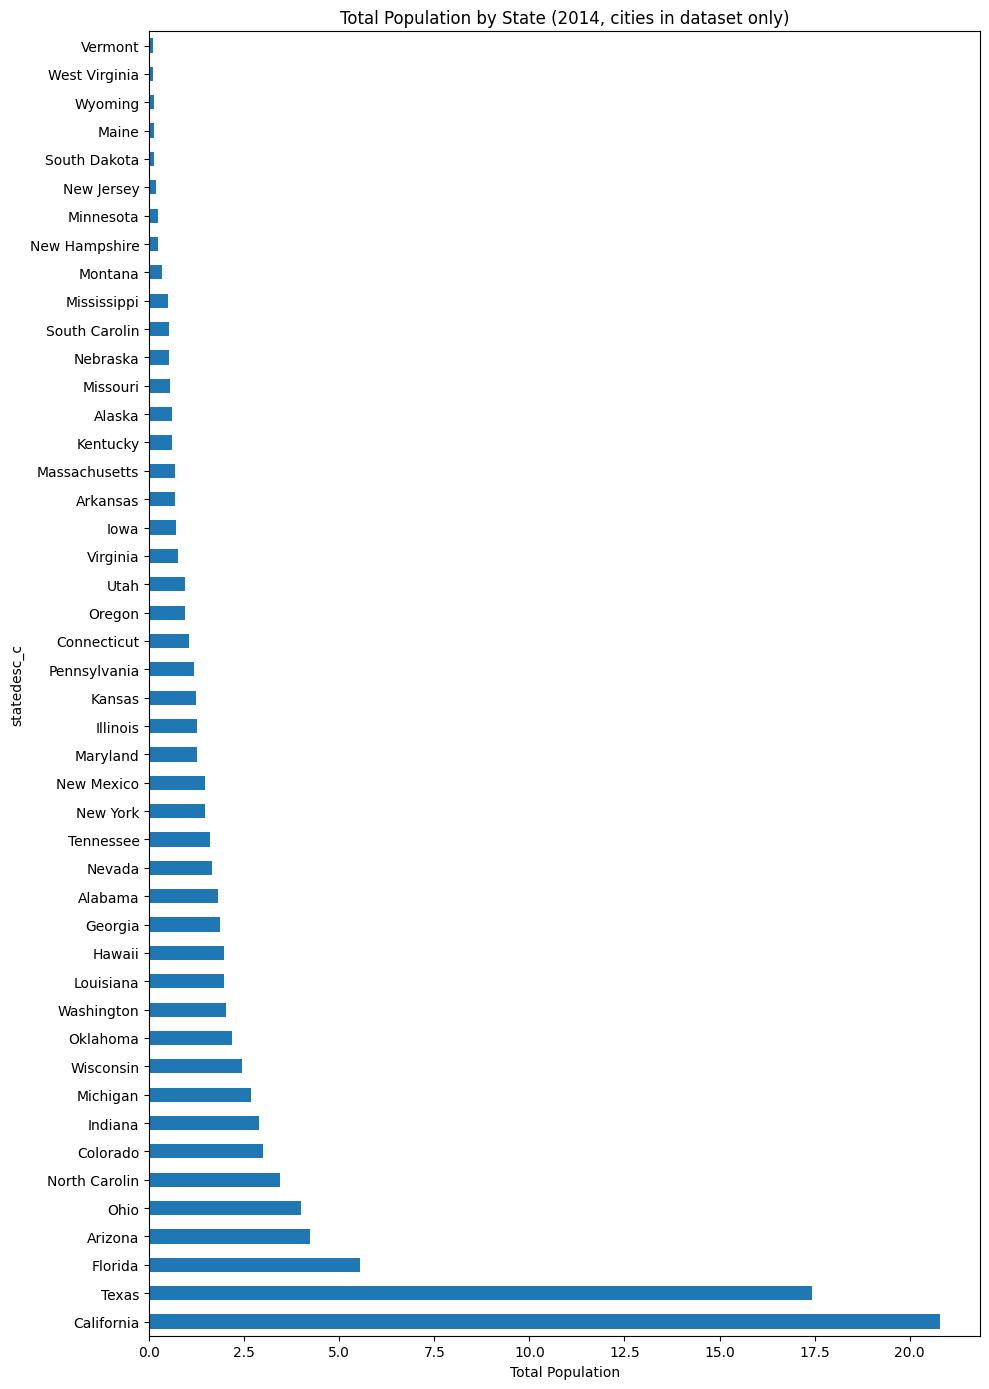

In [23]:
# Filter for 2014 only
df_2014 = df_pivot[df_pivot['year'] == 2014].copy()

# Clean population column - it's stored as string with commas
df_2014['pop'] = df_2014['totalpopulation_c'].str.replace(',', '').astype(float)

# Sum population by state
state_pop_2014 = df_2014.groupby('statedesc_c')['pop'].sum().sort_values(ascending=False)

state_pop_pct = (state_pop_2014 / state_pop_2014.sum() * 100).round(2)
print(state_pop_pct)

# Plot
import matplotlib.pyplot as plt

state_pop_pct.plot(
    kind='barh',
    figsize=(10, 14),
    title='Total Population by State (2014, cities in dataset only)'
)
plt.xlabel('Total Population')
plt.tight_layout()
plt.show()


       statedesc_c  count    pct
40           Texas    220  12.10
4       California    200  11.00
7          Florida     99   5.45
32            Ohio     70   3.85
5         Colorado     60   3.30
19        Michigan     60   3.30
46       Wisconsin     60   3.30
10        Illinois     60   3.30
11         Indiana     54   2.97
31  North Carolina     54   2.97
15       Louisiana     50   2.75
0          Alabama     50   2.75
8          Georgia     48   2.64
44      Washington     40   2.20
34          Oregon     40   2.20
6      Connecticut     40   2.20
41            Utah     40   2.20
29        New York     40   2.20
35    Pennsylvania     36   1.98
30   North Carolin     36   1.98
12            Iowa     30   1.65
28      New Mexico     30   1.65
43        Virginia     30   1.65
33        Oklahoma     30   1.65
3         Arkansas     30   1.65
2          Arizona     30   1.65
13          Kansas     30   1.65
18   Massachusetts     20   1.10
25          Nevada     20   1.10
23        

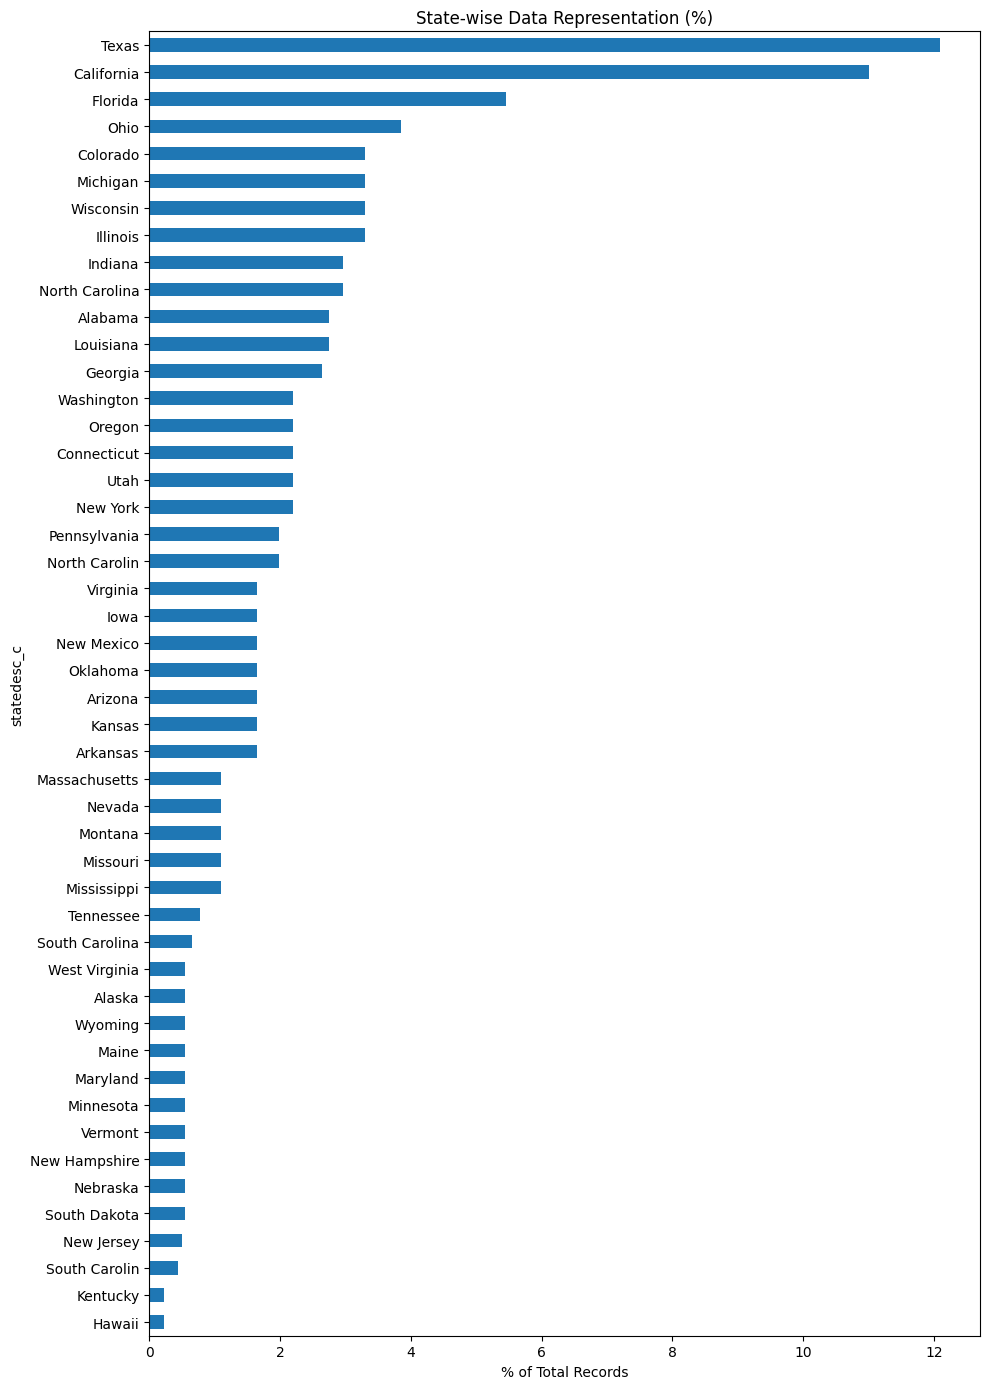

In [15]:
#Records per state
state_counts = df_pivot.groupby('statedesc_c').size().reset_index(name='count')
state_counts['pct'] = (state_counts['count'] / state_counts['count'].sum() * 100).round(2)
state_counts = state_counts.sort_values('pct', ascending=False)
print(state_counts)


#Visualise
import matplotlib.pyplot as plt

state_counts.set_index('statedesc_c')['pct'].sort_values().plot(
    kind='barh',
    figsize=(10, 14),
    title='State-wise Data Representation (%)'
)

plt.xlabel('% of Total Records')
plt.tight_layout()
plt.show()



## Gender

                pct_male_u  pct_female_u
statedesc_c                             
Georgia              48.20         51.80
Massachusetts        48.20         51.80
Maryland             48.25         51.75
Alabama              48.27         51.73
Virginia             48.30         51.70
Mississippi          48.41         51.59
West Virginia        48.58         51.42
Louisiana            48.65         51.35
Maine                48.72         51.28
South Carolina       48.76         51.24
South Carolin        48.78         51.22
Florida              48.79         51.21
Connecticut          48.79         51.21
New York             48.81         51.19
Illinois             48.83         51.17
Missouri             48.84         51.16
Ohio                 48.88         51.12
Tennessee            48.91         51.09
Arkansas             48.92         51.08
North Carolin        48.95         51.05
Michigan             48.96         51.04
New Mexico           49.04         50.96
Kentucky        

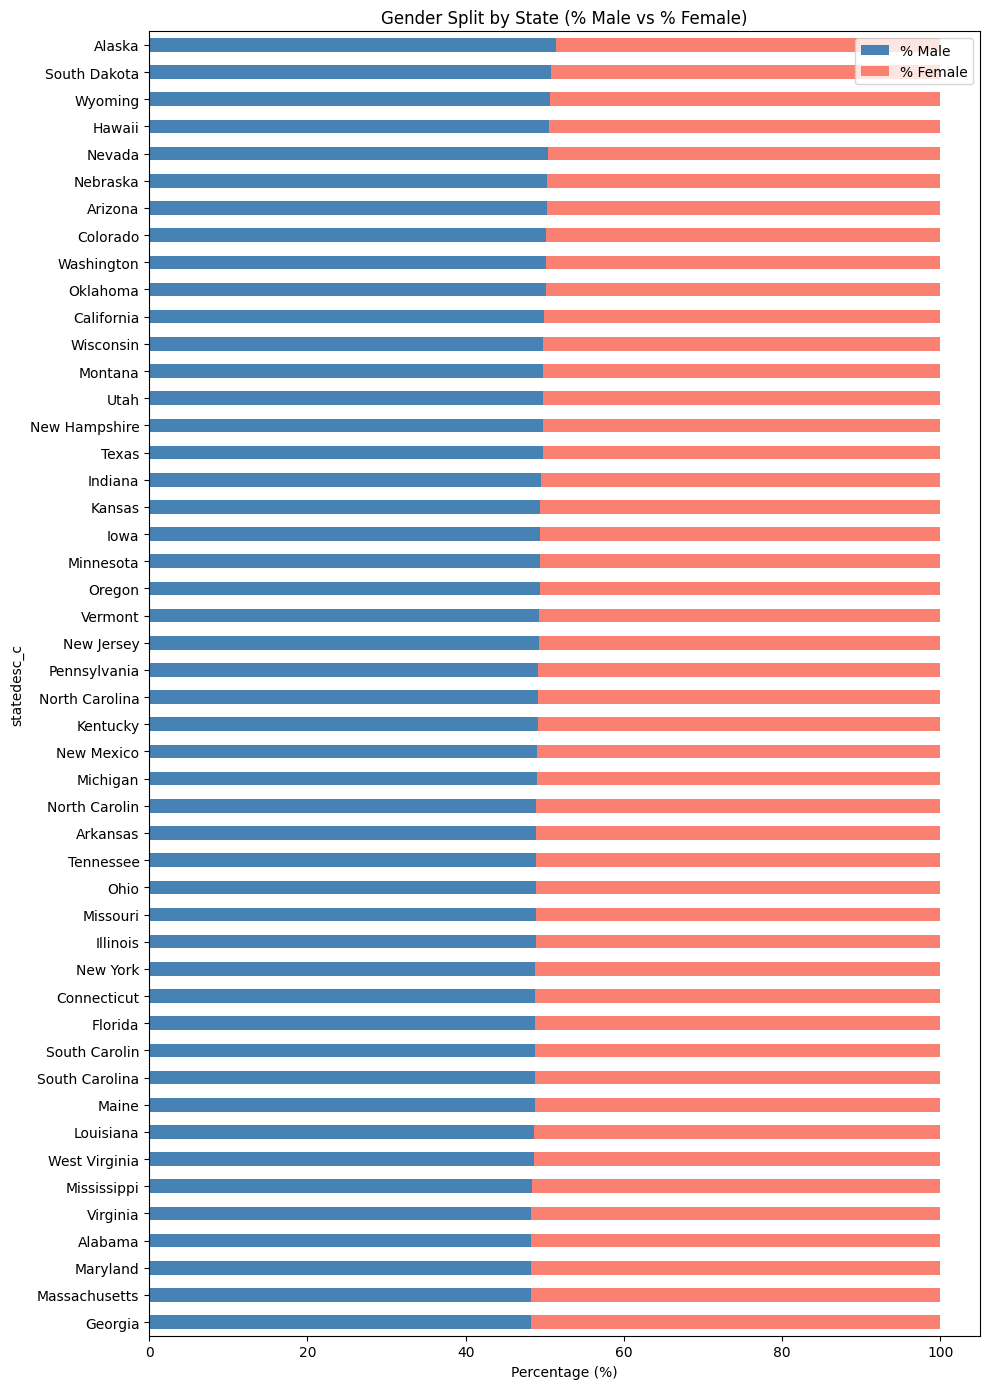

In [13]:
gender_by_state = df_pivot.groupby('statedesc_c')[['pct_male_u', 'pct_female_u']].mean().round(2)
gender_by_state = gender_by_state.sort_values('pct_female_u', ascending=False)
print(gender_by_state)

import matplotlib.pyplot as plt

gender_by_state.plot(
    kind='barh',
    stacked=True,
    figsize=(10, 14),
    color=['steelblue', 'salmon'],
    title='Gender Split by State (% Male vs % Female)'
)

plt.xlabel('Percentage (%)')
plt.legend(['% Male', '% Female'])
plt.tight_layout()
plt.show()

# Univariate Analysis

## CHD - central tendency and spread 

In [ ]:
#CHD country-wise

chd_by_state = df_pivot.groupby('statedesc_c')['CHD'].agg(
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
).round(2)

chd_by_state['IQR'] = chd_by_state['q3'] - chd_by_state['q1']

chd_by_state.sort_values('mean', ascending=True)


,mean,median,std,min,max,q1,q3,IQR
statedesc_c,,,,,,,,
Hawaii,4.18,4.05,0.29,4.0,4.6,4.00,4.22,0.22
Minnesota,4.81,4.85,0.14,4.6,5.0,4.72,4.90,0.18
Colorado,5.02,4.90,0.54,4.2,6.3,4.60,5.52,0.92
Alaska,5.10,5.05,0.26,4.7,5.5,5.00,5.32,0.32
Nebraska,5.17,5.15,0.28,4.7,5.7,5.00,5.35,0.35
New Mexico,5.22,5.30,0.52,4.3,6.1,4.80,5.60,0.80
Montana,5.24,5.20,0.26,4.8,5.7,5.07,5.40,0.33
Wyoming,5.29,5.25,0.27,4.9,5.7,5.12,5.40,0.28
Vermont,5.42,5.50,0.25,4.9,5.8,5.30,5.57,0.27


## CHD over years

['Ohio', 'New Jersey', 'West Virginia', 'Pennsylvania', 'Mississippi']


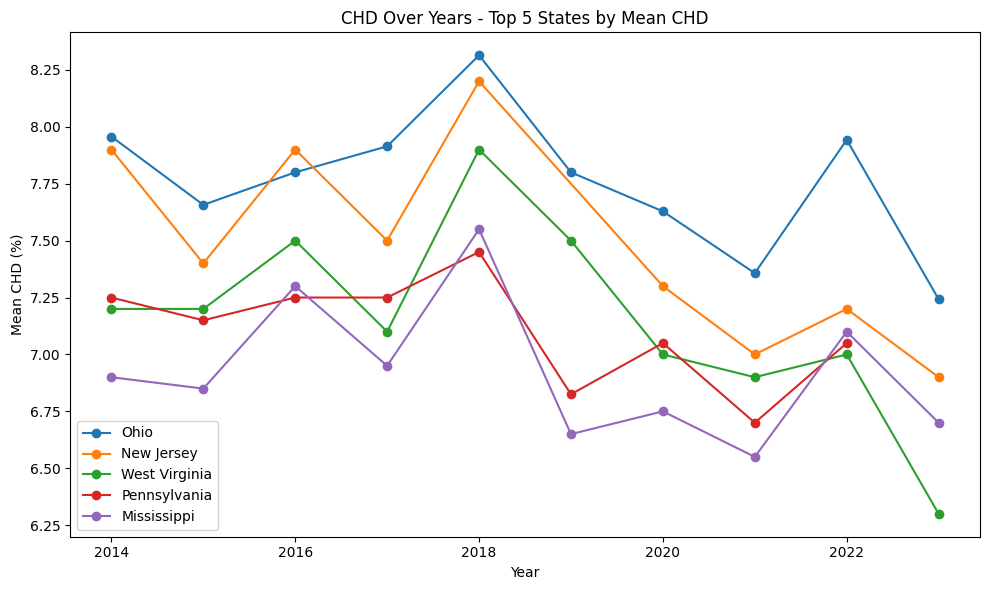

In [ ]:
# Step 1: Get the top 5 states by mean CHD
top5_states = chd_by_state.sort_values('mean', ascending=False).head(5).index.tolist()
print(top5_states)

#Over-years
top5_df = df_pivot[df_pivot['statedesc_c'].isin(top5_states)]

top5_yearly = top5_df.groupby(['year', 'statedesc_c'])['CHD'].mean().reset_index()

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

for state in top5_states:
    state_data = top5_yearly[top5_yearly['statedesc_c'] == state]
    ax.plot(state_data['year'], state_data['CHD'], marker='o', label=state)

ax.set_title('CHD Over Years - Top 5 States by Mean CHD')
ax.set_xlabel('Year')
ax.set_ylabel('Mean CHD (%)')
ax.legend()
plt.tight_layout()
plt.show()


## Outliers (State-wise)

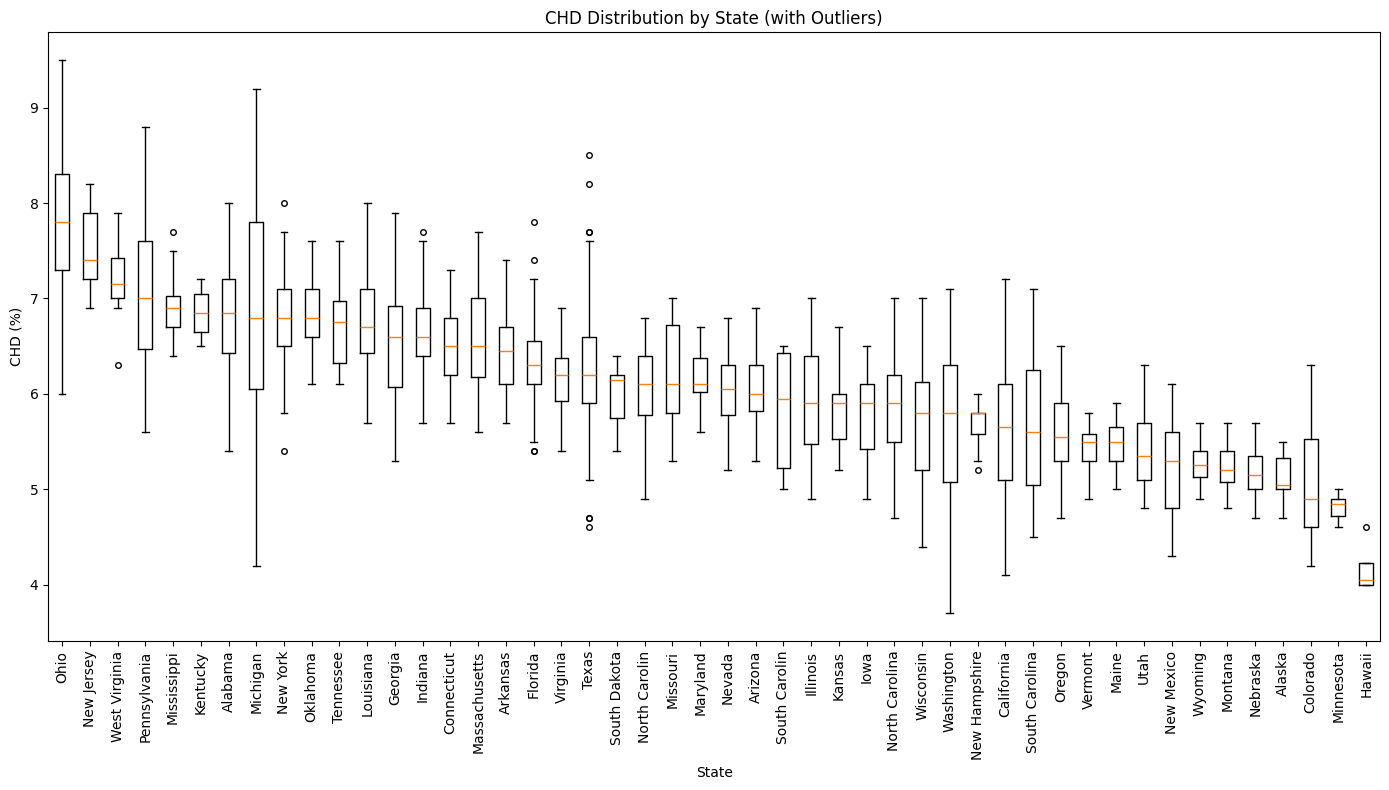

In [17]:
import matplotlib.pyplot as plt

chd_data = df_pivot[['statedesc_c', 'CHD']].dropna()

states_ordered = chd_data.groupby('statedesc_c')['CHD'].median().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(14, 8))

chd_data_sorted = [chd_data[chd_data['statedesc_c'] == state]['CHD'].values for state in states_ordered]

ax.boxplot(chd_data_sorted, flierprops=dict(marker='o', color='red', markersize=4))

ax.set_xticks(range(1, len(states_ordered) + 1))
ax.set_xticklabels(states_ordered, rotation=90)
ax.set_title('CHD Distribution by State (with Outliers)')
ax.set_xlabel('State')
ax.set_ylabel('CHD (%)')
plt.tight_layout()
plt.show()



Southern/Eastern states (Ohio, New Jersey, West Virginia, Mississippi, Pennsylvania) have the highest CHD rates — median around 7.5–8%
Western states (Hawaii, Minnesota, Colorado, Alaska) have the lowest CHD rates — median around 4.5–5.5%
This aligns with the well-known "Stroke Belt" phenomenon in the US South/East

Geography is strongly associated with CHD prevalence, with a clear East-to-West gradient, which might point to differences in lifestyle, demographics, healthcare access, or socioeconomic factors.

Leading Causes and Contributing Factors
Hypertension Management: A major factor is the high prevalence and often poor control of hypertension, which is a key driver of stroke incidence.
Diet and Lifestyle: Southern dietary traditions (high salt, fat, and fried food consumption) combined with lower levels of physical activity contribute significantly.
Environmental Factors: Some studies suggest that the prevalence of soft water in the region may be a factor, though diet and lifestyle are considered more significant contributors.
Stress: Higher levels of chronic stress and "life stressors" are also believed to contribute to the increased risk.

## Yearly Patterns (CHD)

      mean   std  median
year                    
2014  6.34  0.85     6.3
2015  6.20  0.86     6.2
2016  6.37  0.82     6.4
2017  6.16  0.91     6.1
2018  6.60  0.96     6.7
2019  6.00  0.86     6.0
2020  6.08  0.75     6.1
2021  5.72  0.79     5.7
2022  6.21  0.77     6.2
2023  5.80  0.73     5.8


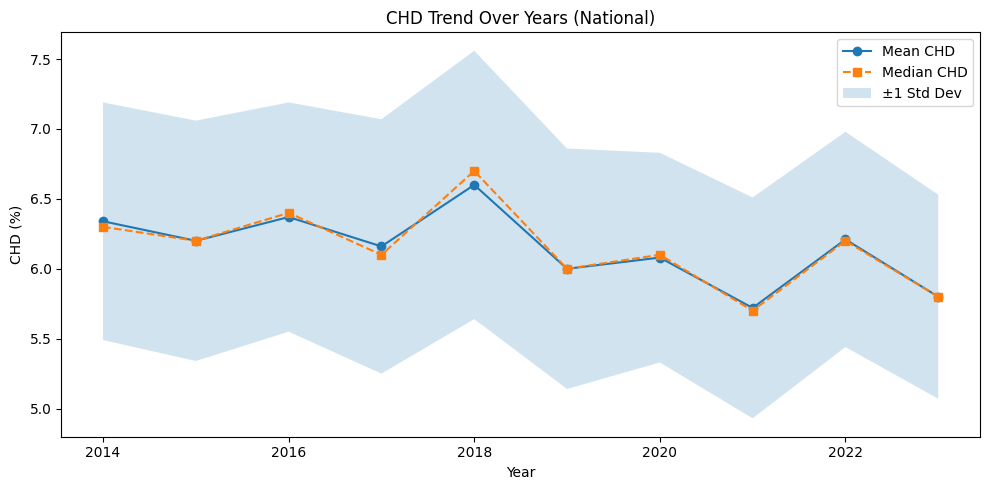

In [ ]:
import matplotlib.pyplot as plt

yearly_chd = df_pivot.groupby('year')['CHD'].agg(['mean', 'std', 'median']).round(2)
print(yearly_chd)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_chd.index, yearly_chd['mean'], marker='o', label='Mean CHD')
ax.plot(yearly_chd.index, yearly_chd['median'], marker='s', linestyle='--', label='Median CHD')
ax.fill_between(yearly_chd.index, 
                yearly_chd['mean'] - yearly_chd['std'], 
                yearly_chd['mean'] + yearly_chd['std'], 
                alpha=0.2, label='±1 Std Dev')

ax.set_title('CHD Trend Over Years (National)')
ax.set_xlabel('Year')
ax.set_ylabel('CHD (%)')
ax.legend()
plt.tight_layout()
plt.show()

## Stroke - central tendency and spread 

In [19]:
#STROKE country-wise

stroke_by_state = df_pivot.groupby('statedesc_c')['STROKE'].agg(
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
).round(2)

stroke_by_state['IQR'] = stroke_by_state['q3'] - stroke_by_state['q1']

stroke_by_state.sort_values('mean', ascending=True)

,mean,median,std,min,max,q1,q3,IQR
statedesc_c,,,,,,,,
Minnesota,2.43,2.40,0.09,2.3,2.6,2.40,2.50,0.10
Hawaii,2.48,2.50,0.05,2.4,2.5,2.48,2.50,0.02
Wyoming,2.59,2.60,0.11,2.4,2.7,2.50,2.70,0.20
Nebraska,2.60,2.60,0.12,2.4,2.8,2.50,2.70,0.20
Maine,2.64,2.65,0.10,2.5,2.8,2.60,2.70,0.10
Alaska,2.70,2.60,0.13,2.6,2.9,2.60,2.80,0.20
Colorado,2.70,2.70,0.33,2.2,3.5,2.50,2.92,0.42
Montana,2.72,2.70,0.11,2.5,2.9,2.60,2.80,0.20
New Mexico,2.76,2.75,0.29,2.3,3.3,2.52,3.00,0.48


## Outliers (State-wise)

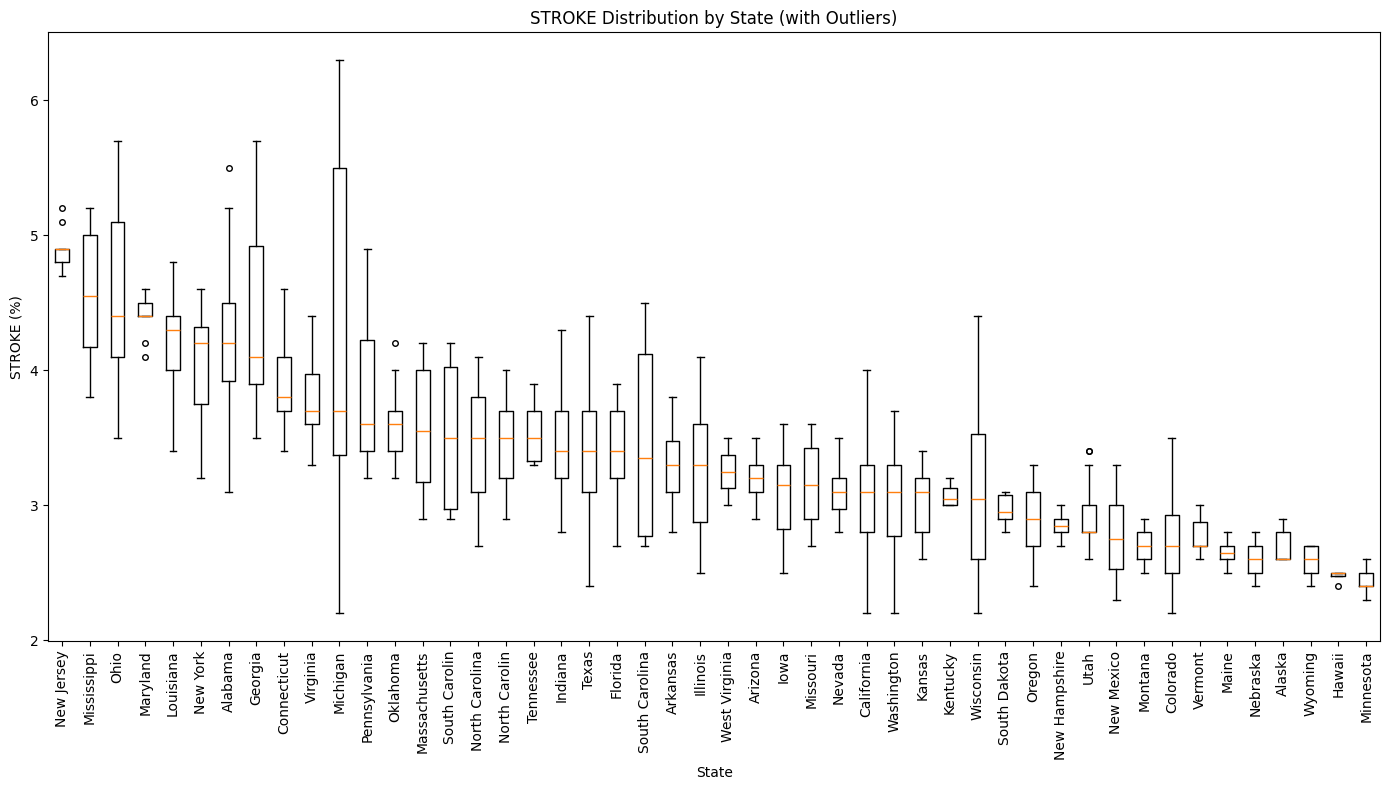

In [20]:
import matplotlib.pyplot as plt

stroke_data = df_pivot[['statedesc_c', 'STROKE']].dropna()

states_ordered = stroke_data.groupby('statedesc_c')['STROKE'].median().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(14, 8))

stroke_data_sorted = [stroke_data[stroke_data['statedesc_c'] == state]['STROKE'].values for state in states_ordered]

ax.boxplot(stroke_data_sorted, flierprops=dict(marker='o', color='red', markersize=4))

ax.set_xticks(range(1, len(states_ordered) + 1))
ax.set_xticklabels(states_ordered, rotation=90)
ax.set_title('STROKE Distribution by State (with Outliers)')
ax.set_xlabel('State')
ax.set_ylabel('STROKE (%)')
plt.tight_layout()
plt.show()

## Yearly Patterns - Stroke

      mean   std  median
year                    
2014  3.29  0.65     3.2
2015  3.38  0.71     3.2
2016  3.48  0.72     3.4
2017  3.43  0.69     3.4
2018  3.54  0.69     3.4
2019  3.58  0.72     3.5
2020  3.30  0.68     3.2
2021  3.25  0.60     3.2
2022  3.58  0.67     3.5
2023  3.43  0.66     3.3


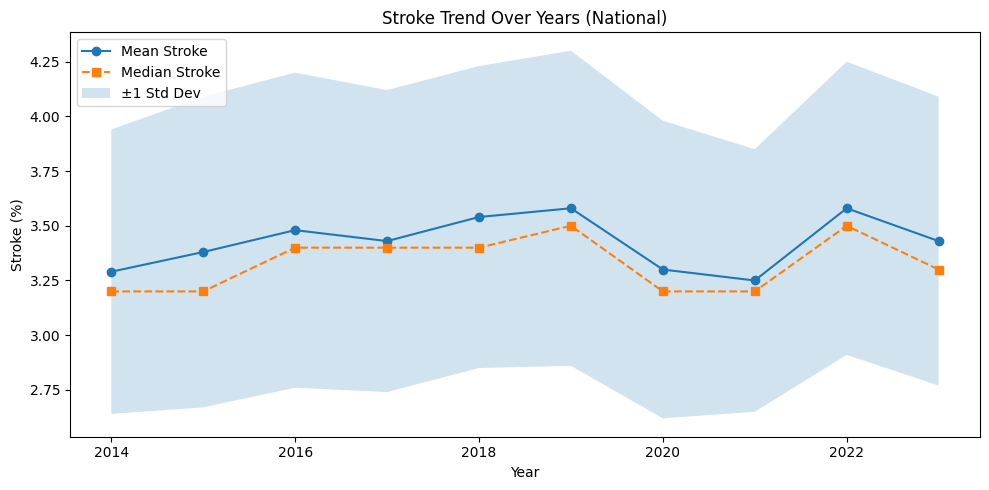

In [26]:
import matplotlib.pyplot as plt

yearly_stroke = df_pivot.groupby('year')['STROKE'].agg(['mean', 'std', 'median']).round(2)
print(yearly_stroke)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_stroke.index, yearly_stroke['mean'], marker='o', label='Mean Stroke')
ax.plot(yearly_stroke.index, yearly_stroke['median'], marker='s', linestyle='--', label='Median Stroke')
ax.fill_between(yearly_stroke.index, 
                yearly_stroke['mean'] - yearly_stroke['std'], 
                yearly_stroke['mean'] + yearly_stroke['std'], 
                alpha=0.2, label='±1 Std Dev')

ax.set_title('Stroke Trend Over Years (National)')
ax.set_xlabel('Year')
ax.set_ylabel('Stroke (%)')
ax.legend()
plt.tight_layout()
plt.show()

## Weather Variable Trends over Years

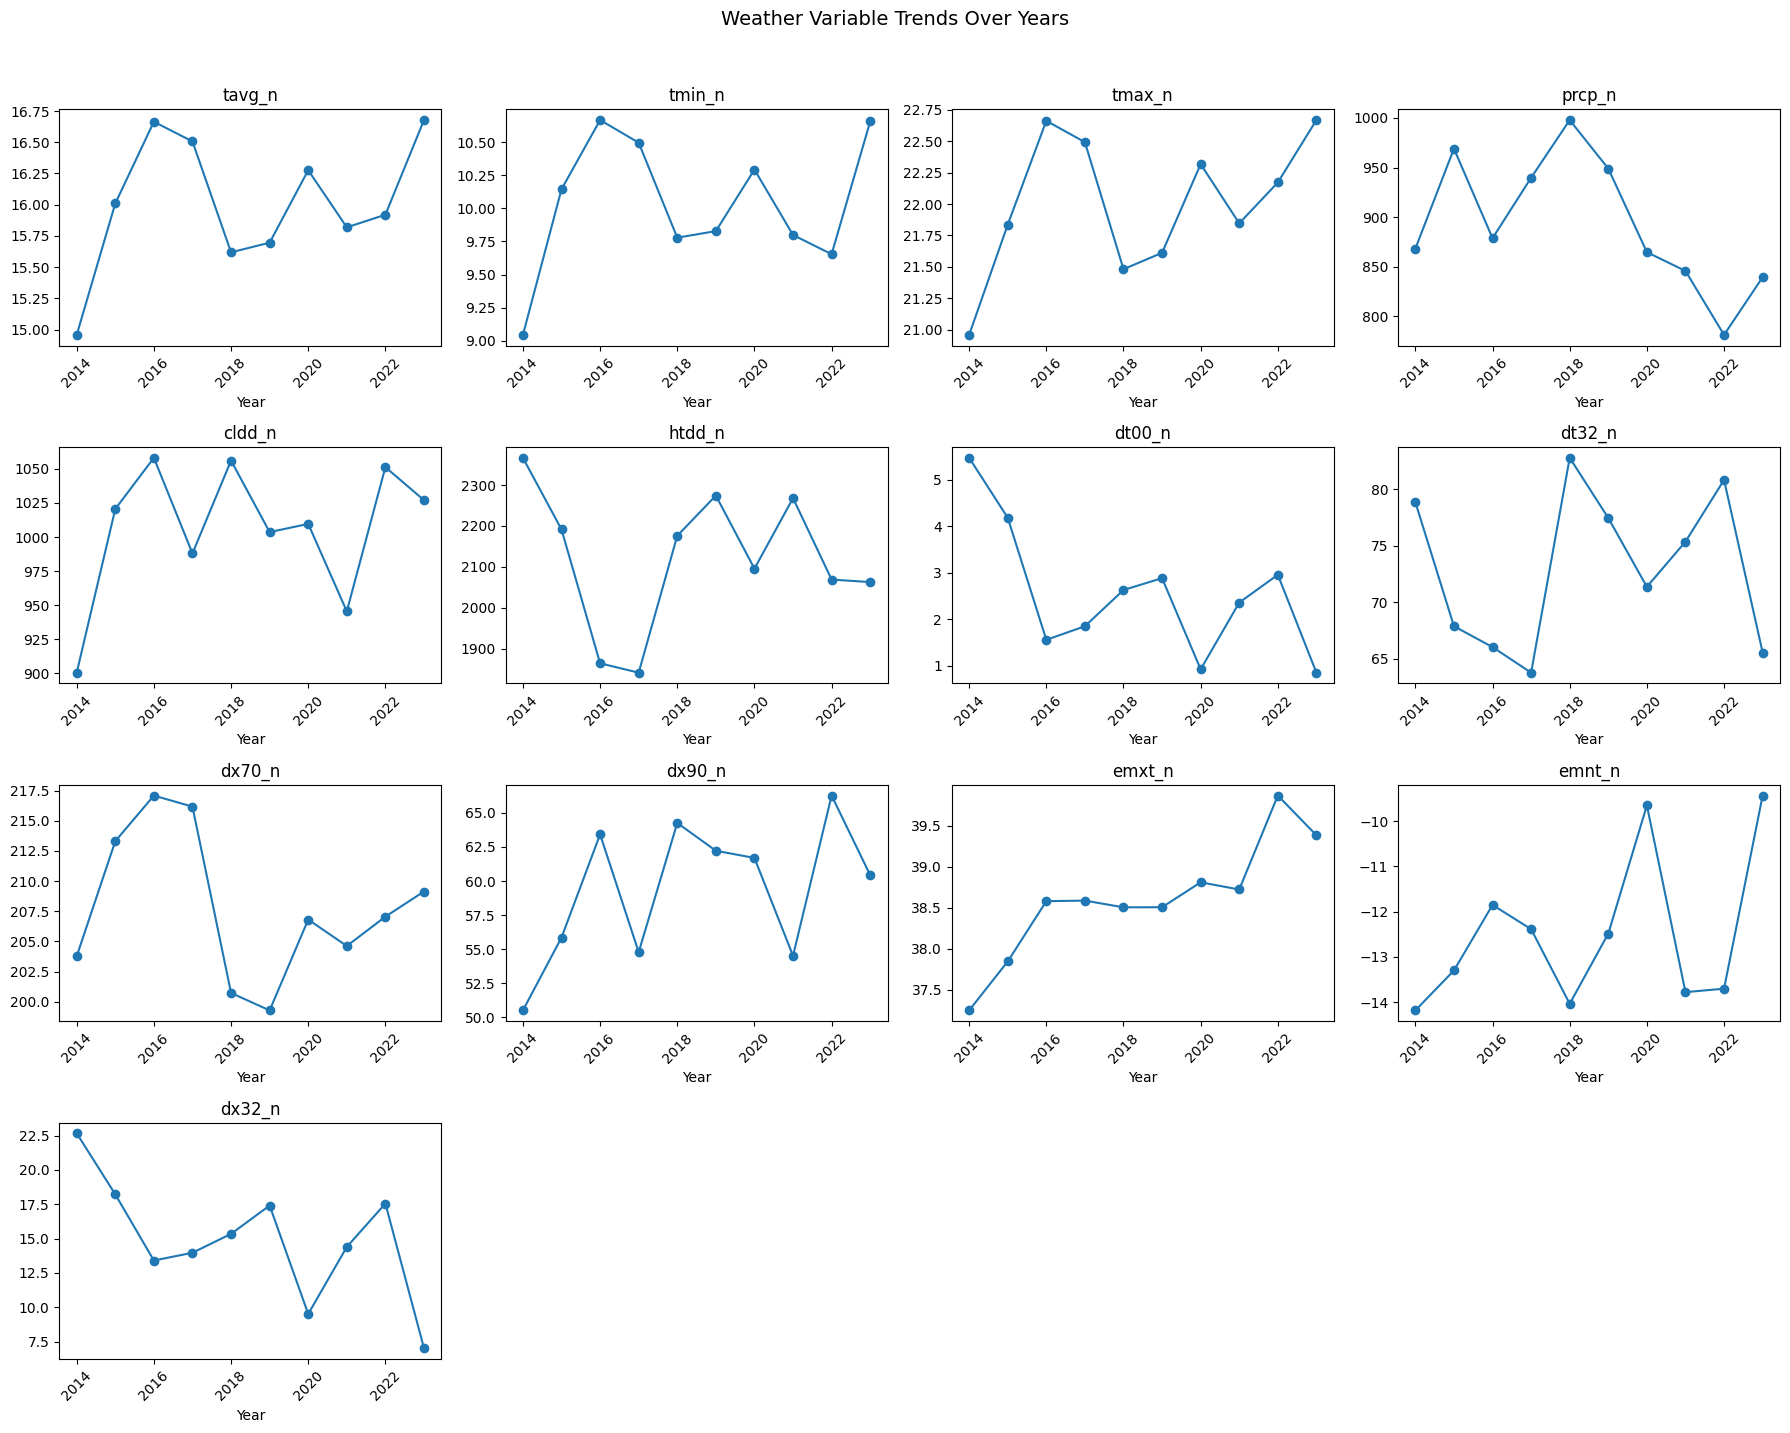

In [27]:
weather_cols = ['tavg_n', 'tmin_n', 'tmax_n', 'prcp_n', 'cldd_n', 'htdd_n', 
                'dt00_n', 'dt32_n', 'dx70_n', 'dx90_n', 'emxt_n', 'emnt_n', 'dx32_n']

# See how much data each has
df_pivot[weather_cols].isnull().mean().mul(100).round(2).sort_values()

import matplotlib.pyplot as plt

weather_yearly = df_pivot.groupby('year')[weather_cols].mean()

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(weather_cols):
    axes[i].plot(weather_yearly.index, weather_yearly[col], marker='o')
    axes[i].set_title(col)
    axes[i].set_xlabel('Year')
    axes[i].tick_params(axis='x', rotation=45)

# hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Weather Variable Trends Over Years', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



In [28]:
# How many cities have weather data each year?
df_pivot.groupby('year')[['tavg_n', 'prcp_n', 'tmin_n']].count()


,tavg_n,prcp_n,tmin_n
year,,,
2014,169,176,171
2015,173,179,173
2016,179,184,179
2017,174,180,175
2018,164,173,165
2019,164,171,166
2020,170,173,171
2021,161,162,161
2022,166,173,167


In [29]:
# See which cities appear in 2014 but not 2016, and vice versa
cities_2014 = set(df_pivot[df_pivot['year'] == 2014].dropna(subset=['tavg_n'])['locationname_c'])
cities_2016 = set(df_pivot[df_pivot['year'] == 2016].dropna(subset=['tavg_n'])['locationname_c'])

print("In 2014 but not 2016:", cities_2014 - cities_2016)
print("In 2016 but not 2014:", cities_2016 - cities_2014)


In 2014 but not 2016: {'Miami', 'Seattle'}
In 2016 but not 2014: {'Yuma', 'Odessa', 'St. George', 'Oxnard', 'Warner Robins', 'Port St. Lucie', 'Killeen', 'Jonesboro', 'Youngstown', 'Detroit', 'Winston-Salem'}


                avg_temp  mean_chd
statedesc_c                       
Ohio               17.40      7.76
New Jersey         12.70      7.48
West Virginia      13.77      7.16
Pennsylvania       11.55      7.11
Mississippi        20.04      6.93
Kentucky           13.77      6.85
Alabama            18.95      6.84
Oklahoma           16.67      6.84
Michigan           10.04      6.83
Louisiana          21.01      6.77
New York            9.93      6.74
Tennessee          15.67      6.71
Indiana            12.12      6.68
Massachusetts       9.90      6.60
Georgia            27.50      6.56
Connecticut        11.76      6.49
Arkansas           16.12      6.46
Florida            23.19      6.33
Texas              20.72      6.28
Missouri           13.98      6.21
Maryland           14.09      6.18
Virginia           14.96      6.17
Arizona            23.73      6.08
North Carolin      22.23      6.06
South Dakota        8.24      6.01
Nevada             17.52      6.00
Illinois           1

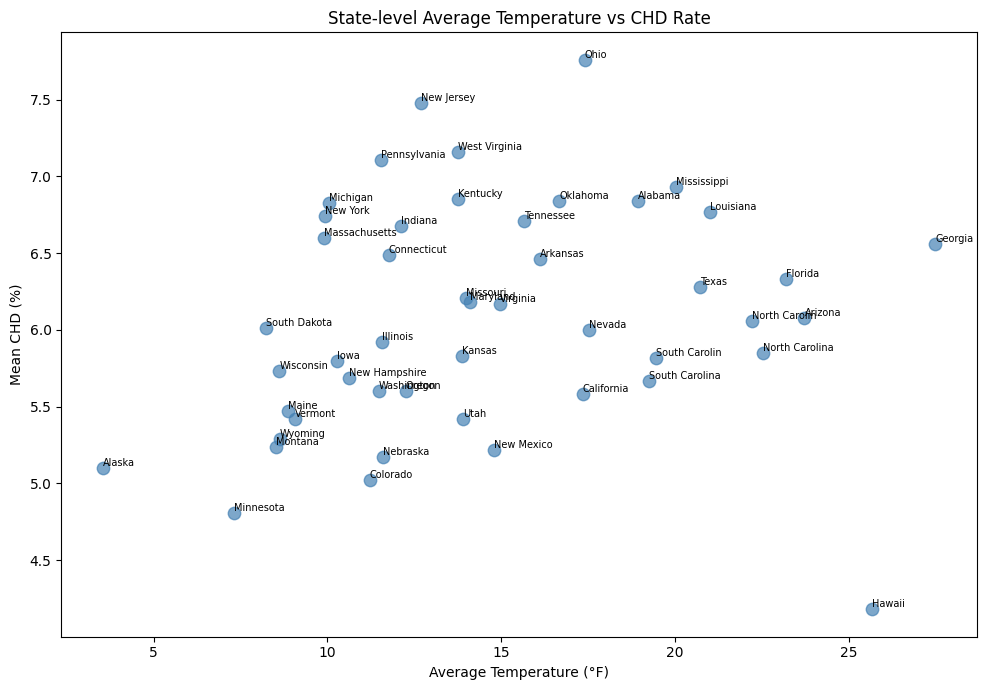

In [35]:
import matplotlib.pyplot as plt

# Aggregate to state level
state_temp_chd = df_pivot.groupby('statedesc_c').agg(
    avg_temp=('tavg_n', 'mean'),
    mean_chd=('CHD', 'mean')
).dropna().round(2)

print(state_temp_chd.sort_values('mean_chd', ascending=False))

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(state_temp_chd['avg_temp'], state_temp_chd['mean_chd'], 
           color='steelblue', s=80, alpha=0.7)

# Label each dot with state name
for state, row in state_temp_chd.iterrows():
    ax.annotate(state, (row['avg_temp'], row['mean_chd']), 
                fontsize=7, ha='left', va='bottom')

ax.set_xlabel('Average Temperature (°F)')
ax.set_ylabel('Mean CHD (%)')
ax.set_title('State-level Average Temperature vs CHD Rate')
plt.tight_layout()
plt.show()


In [33]:
import subprocess
subprocess.run(['pip', 'install', 'seaborn'])


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


CompletedProcess(args=['pip', 'install', 'seaborn'], returncode=0)

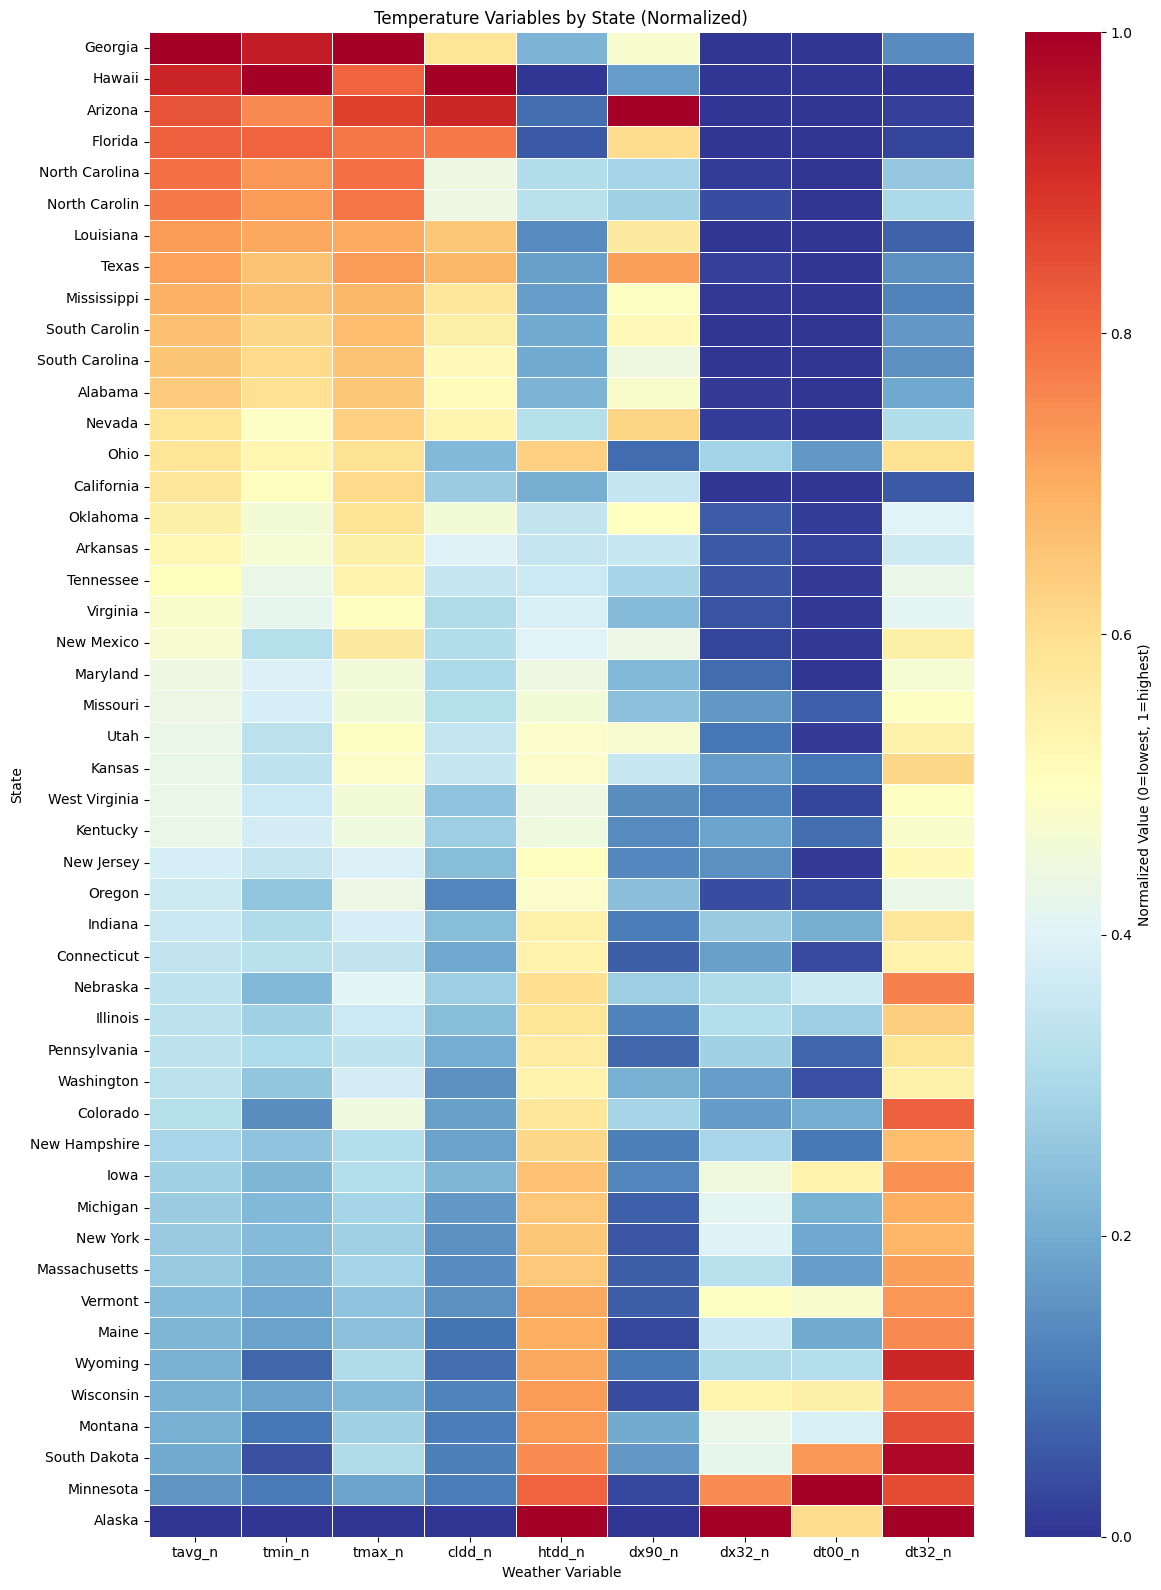

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

temp_cols = ['tavg_n', 'tmin_n', 'tmax_n', 'cldd_n', 'htdd_n', 'dx90_n', 'dx32_n', 'dt00_n', 'dt32_n']

state_temp = df_pivot.groupby('statedesc_c')[temp_cols].mean().round(2)

# Normalize each column (0-1) so different units are comparable
state_temp_norm = (state_temp - state_temp.min()) / (state_temp.max() - state_temp.min())
state_temp_norm = state_temp_norm.sort_values('tavg_n', ascending=False)

plt.figure(figsize=(12, 16))
sns.heatmap(state_temp_norm, 
            cmap='RdYlBu_r',
            annot=False,
            linewidths=0.5,
            cbar_kws={'label': 'Normalized Value (0=lowest, 1=highest)'})

plt.title('Temperature Variables by State (Normalized)')
plt.xlabel('Weather Variable')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('../EDA/temp_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Temperature Outliers

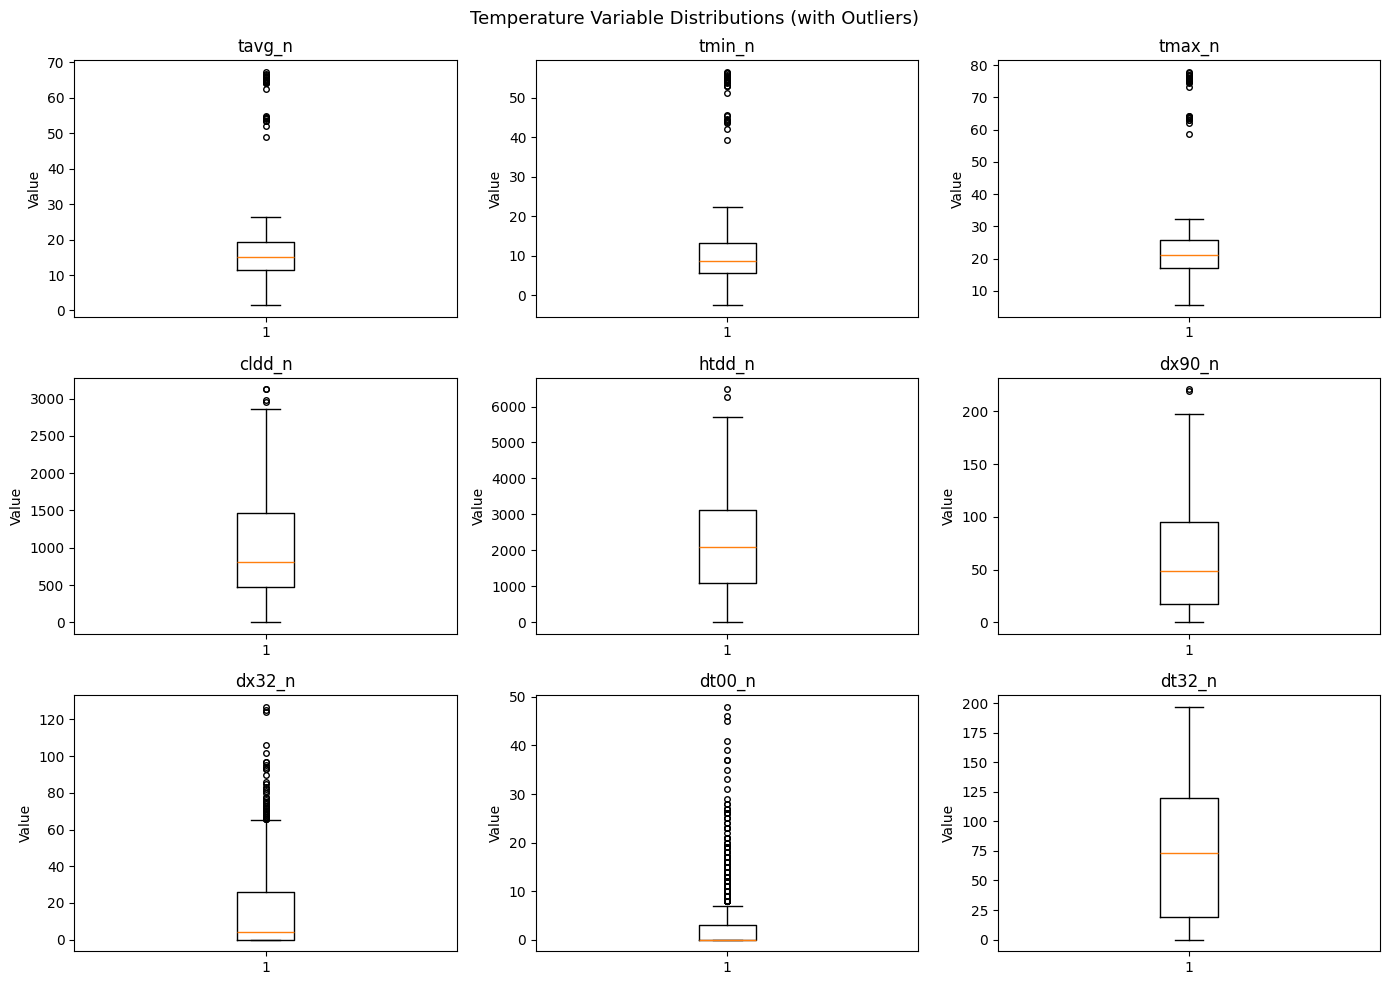

In [38]:

import matplotlib.pyplot as plt

temp_cols = ['tavg_n', 'tmin_n', 'tmax_n', 'cldd_n', 'htdd_n', 'dx90_n', 'dx32_n', 'dt00_n', 'dt32_n']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(temp_cols):
    axes[i].boxplot(df_pivot[col].dropna(), 
                    flierprops=dict(marker='o', color='red', markersize=4))
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.suptitle('Temperature Variable Distributions (with Outliers)', fontsize=13)
plt.tight_layout()
plt.show()
